In [17]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [18]:
df = pd.read_csv("../data/movies.csv")

In [19]:
df.head()


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


## Inspect dataframe structure

In [20]:
df.shape

(7668, 15)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [22]:
df.isna().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

## Prepare clean dataset for analysys

In [23]:
colums = ["name", "genre", "year", "score", "votes", "runtime"]
df_movies = df[colums]
df_movies

,name,genre,year,score,votes,runtime
0,The Shining,Drama,1980,8.4,927000.0,146.0
1,The Blue Lagoon,Adventure,1980,5.8,65000.0,104.0
2,Star Wars: Episode V - The Empire Strikes Back,Action,1980,8.7,1200000.0,124.0
3,Airplane!,Comedy,1980,7.7,221000.0,88.0
4,Caddyshack,Comedy,1980,7.3,108000.0,98.0
...,...,...,...,...,...,...
7663,More to Life,Drama,2020,3.1,18.0,90.0
7664,Dream Round,Comedy,2020,4.7,36.0,90.0
7665,Saving Mbango,Drama,2020,5.7,29.0,NaN
7666,It's Just Us,Drama,2020,NaN,NaN,120.0


In [24]:
df_movies.isna().sum()

name       0
genre      0
year       0
score      3
votes      3
runtime    4
dtype: int64

In [25]:
df_movies = df_movies.dropna()
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7661 entries, 0 to 7667
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     7661 non-null   object 
 1   genre    7661 non-null   object 
 2   year     7661 non-null   int64  
 3   score    7661 non-null   float64
 4   votes    7661 non-null   float64
 5   runtime  7661 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 419.0+ KB


In [26]:
df_movies["score"].describe().round(2)

count    7661.00
mean        6.39
std         0.97
min         1.90
25%         5.80
50%         6.50
75%         7.10
max         9.30
Name: score, dtype: float64

### Score Distribution — Summary Statistics

The dataset contains 7,668 movies, with 7,661 non-null values for the score column.
The number of missing values is very small and does not significantly affect the analysis.

The average movie rating is 6.39, while the median rating is 6.5.
Since the mean is slightly lower than the median, this suggests a slight skew toward lower-rated movies.

The standard deviation is 0.97, which indicates a moderate spread of ratings.
Most movies have scores approximately between 5.4 and 7.4.

Half of the movies (the interquartile range) fall within a relatively narrow range from 5.8 to 7.1, meaning that the majority of films receive similar ratings.

The minimum score in the dataset is 1.9, and the maximum score is 9.3.
These extreme values are rare and represent outliers rather than typical movies.

Overall, most movies in the dataset are rated between 6 and 7, with very low and very high ratings occurring infrequently.

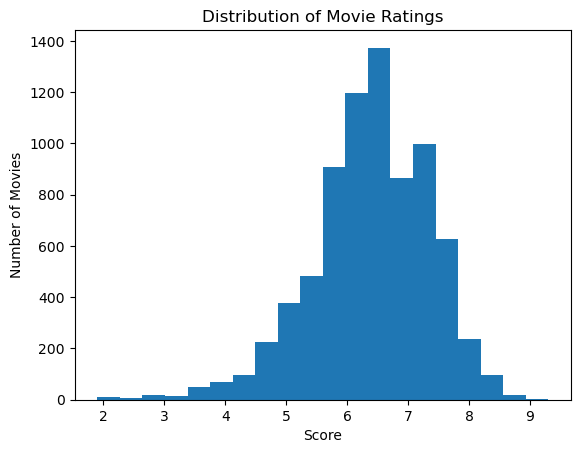

In [31]:
df_movies["score"].plot(kind="hist", bins=20)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Score")
plt.ylabel("Number of Movies")

plt.show()

### Score Distribution — Histogram

The histogram shows that movie ratings are concentrated between approximately 6 and 7.  
This confirms the summary statistics, where the mean score is 6.39 and the median is 6.5.

The distribution is slightly skewed toward lower ratings, indicating that a small number of low-rated movies pull the average down.  
Very low and very high ratings occur infrequently and represent a small portion of the dataset.
